## Stakeholder hypothesis: position → injury/workload risk

**Stakeholder:** Medical/Performance staff
**Their question:** Which workload patterns are worth flagging before
signing a player?
**Hypothesis to test:** a player's position predicts their
injury/workload risk.

**Dependency: this needs `dbt run` first.** `position`, `sub_position`
and `date_of_birth` were added to `player_key_map` -> `player_injury_workload`
but won't exist in the DuckDB table until the marts are rebuilt. Run
`dbt run` from inside `dbt/` before running this notebook, or the first
query below will fail with a "column not found" error.

Paste these cells into `03_risk_score.ipynb` as a new section, or run
standalone -- self-contained, own DB connection, namespaced variables.

In [1]:
import sys
print(sys.executable)

c:\Users\mahmo\miniconda3\python.exe


In [2]:
import duckdb
import pandas as pd
from scipy import stats

DB_PATH = "../data/warehouse.duckdb"  # adjust if this notebook lives elsewhere

# `with` instead of a bare connect()/close() pair -- guarantees the
# connection closes even if a query below raises an error, so a failed
# cell can't leave the DuckDB file locked for other processes (e.g. dbt).
# (This is exactly what happened the first time this cell ran here -- see
# DEBUGGING_LOG.md.)
with duckdb.connect(DB_PATH, read_only=True) as con:
    workload = con.sql("""
        SELECT player_id, canonical_name, position, sub_position,
               injury_count, total_days_missed, total_90s_played
        FROM main.player_injury_workload
    """).df()

print(f"{len(workload):,} players")
print(workload["position"].value_counts(dropna=False))

1,959 players
position
Defender      672
Midfield      589
Attack        478
Goalkeeper    217
Missing         3
Name: count, dtype: int64


### Step 1 -- turn raw counts into a workload-adjusted rate

Raw `injury_count` alone is misleading here: a player who's played 300
games has had far more *chances* to get injured than one who's played
30, regardless of position. Comparing raw counts would really just be
comparing who's played the most, not who's more injury-prone. Dividing
by playing time (`total_90s_played`) controls for that exposure.

Players with `total_90s_played == 0` can't get a rate (divide by zero)
and are excluded and reported separately, not silently dropped.

In [3]:
n_zero_exposure = (workload["total_90s_played"] == 0).sum()
print(f"Excluding {n_zero_exposure} player(s) with 0 recorded 90s played "
      f"(can't compute a rate) out of {len(workload)} total.")

rated = workload[workload["total_90s_played"] > 0].copy()
rated["injuries_per_1000_90s"] = rated["injury_count"] / rated["total_90s_played"] * 1000
rated["days_missed_per_1000_90s"] = rated["total_days_missed"] / rated["total_90s_played"] * 1000

Excluding 1310 player(s) with 0 recorded 90s played (can't compute a rate) out of 1959 total.


### Step 2 -- a minimum-exposure floor

A player with e.g. 2 total 90s played and 1 injury gets a rate of 500
injuries per 1000 90s -- technically correct, practically noise from a
tiny sample. Set a floor so single small-sample players don't dominate
the comparison; same "no silent caps" approach as
`hypothesis_injury_recency_vs_value.ipynb` -- print how many get excluded
and why, rather than just dropping them.

In [4]:
MIN_90S_PLAYED = 10  # ~900 minutes; adjust if this excludes too much/little of your data

n_below_floor = (rated["total_90s_played"] < MIN_90S_PLAYED).sum()
print(f"Excluding {n_below_floor} of {len(rated)} players with < {MIN_90S_PLAYED} "
      f"total 90s played (unreliable rate from too little playing time).")

rated_floor = rated[rated["total_90s_played"] >= MIN_90S_PLAYED].copy()

Excluding 67 of 649 players with < 10 total 90s played (unreliable rate from too little playing time).


### Step 3 -- summarize by position

Two different rate calculations are shown on purpose: `mean_of_player_rates`
(average each player's own rate, sensitive to small-sample noise even
after the floor) and `group_rate` (total injuries / total 90s for the
whole position group -- more stable, weights heavily-played players more
realistically). Prefer `group_rate` for the headline number.

In [5]:
position_summary = (
    rated_floor.groupby("position")
    .agg(
        n_players=("player_id", "count"),
        total_90s_played=("total_90s_played", "sum"),
        total_injuries=("injury_count", "sum"),
        mean_of_player_rates=("injuries_per_1000_90s", "mean"),
    )
)
position_summary["group_rate_per_1000_90s"] = (
    position_summary["total_injuries"] / position_summary["total_90s_played"] * 1000
)
position_summary = position_summary.round(2).sort_values("group_rate_per_1000_90s", ascending=False)
position_summary

,n_players,total_90s_played,total_injuries,mean_of_player_rates,group_rate_per_1000_90s
position,,,,,
Defender,217,374487.56,1866,24.44,4.98
Attack,131,192377.50,919,18.21,4.78
Midfield,182,266765.14,1140,19.69,4.27
Goalkeeper,52,103603.41,192,17.17,1.85


### Step 4 -- is the difference across positions statistically real?

Kruskal-Wallis is the multi-group version of the Mann-Whitney test used
in the recency-vs-value notebook -- it checks whether at least one
position's rate distribution differs from the others, without assuming
normally-distributed rates (which injury rates usually aren't).
Significant here means "position matters somewhere", not "every position
differs from every other" -- follow-up pairwise tests would be needed to
say which specific positions differ, if that level of detail matters for
the write-up.

In [6]:
groups = [g["injuries_per_1000_90s"].values for _, g in rated_floor.groupby("position")]
group_labels = list(rated_floor.groupby("position").groups.keys())

h_stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis across {len(group_labels)} positions ({', '.join(map(str, group_labels))}):")
print(f"H={h_stat:.2f}, p-value={p_value:.4f}")
print("--> statistically significant at p<0.05" if p_value < 0.05 else "--> not significant at p<0.05")

Kruskal-Wallis across 4 positions (Attack, Defender, Goalkeeper, Midfield):
H=1.82, p-value=0.6096
--> not significant at p<0.05


### Step 5 -- visualize it

`showfliers=False` again -- same reasoning as the recency notebook: a
handful of extreme per-player rates (tiny-but-above-floor playing time
with a couple of bad-luck injuries) will otherwise swamp the plot.

C:\Users\mahmo\AppData\Local\Temp\ipykernel_24844\56699761.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=[str(g) for g in group_labels], showfliers=False)


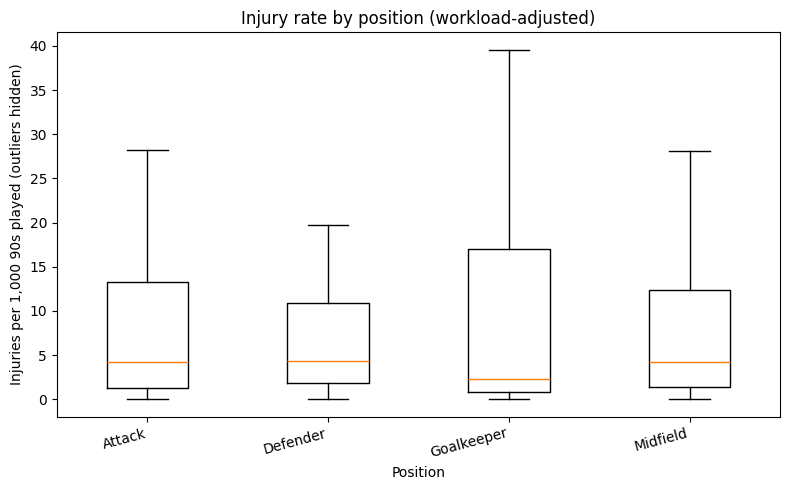

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = [rated_floor.loc[rated_floor["position"] == p, "injuries_per_1000_90s"] for p in group_labels]
ax.boxplot(plot_data, labels=[str(g) for g in group_labels], showfliers=False)
ax.set_ylabel("Injuries per 1,000 90s played (outliers hidden)")
ax.set_xlabel("Position")
ax.set_title("Injury rate by position (workload-adjusted)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Caveats worth stating explicitly in the writeup

- `position` here is each player's single current primary position from
  the source data -- it doesn't capture players who changed position
  over their career, or `sub_position` detail (e.g. Centre-Back vs
  Full-Back likely have different injury profiles but get grouped
  together under "Defender"). Worth rerunning this by `sub_position` if
  the top-level result looks interesting, sample size per group permitting.
- This measures injury *frequency* per playing time, not injury
  *severity* or *type* -- a position with fewer but longer-duration
  injuries wouldn't necessarily show up as "riskier" here. `total_days_missed`
  / `total_90s_played` (computed above but not yet plotted) is worth a
  second pass at this if frequency alone isn't telling a clear story.
- Small positions (e.g. goalkeepers are typically a small fraction of any
  squad) will have fewer players and a noisier rate even after the
  MIN_90S_PLAYED floor -- check `n_players` per group in the summary
  table before treating a small group's rate as reliable.
- Worth a line on the Tableau "Flagged: Known Data Limits" sheet if any
  of the above turn out to matter for your actual numbers.